# **Soybean  데이터에 대한 비전 트랜스포머 모델**

* 런타임 환경이 GPU로 설정되지 않으면 시간이 많이 걸릴수 있습니다.


# 라이브러리 불러오기

In [1]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt; import random
import tensorflow as tf; from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, GlobalAveragePooling1D
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast # 데이터 증강용
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings; warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 41.8 MB/s eta 0:00:00


# 트랜스포머용 클래스 불러오기

In [2]:
!wget https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_transformers.py  # 클래스가 정의된 파일 지정
from mini_transformers import TextEmbedding, PatchEmbedding, TimeSeriesEmbedding, TransformerBlock

--2026-08-02 05:02:33--  https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_transformers.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7391 (7.2K) [text/plain]
Saving to: ‘mini_transformers.py’

mini_transformers.p 100%[===================>]   7.22K  --.-KB/s    in 0s      

2026-08-02 05:02:33 (105 MB/s) - ‘mini_transformers.py’ saved [7391/7391]



📌[실습 04-28] 데이터셋 불러오기

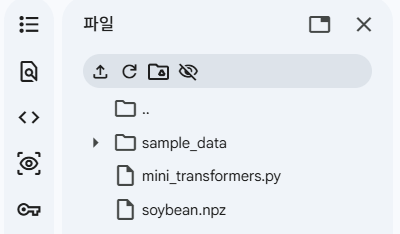

### 이 데이터는 이미 정규화가 되어 있습니다.

In [4]:
df=np.load('soybean.npz')  # 이미 정규화
x_train=df['x_train']; x_test=df['x_test']
y_train=df['y_train']; y_test=df['y_test']

print(f"훈련용 데이터: 입력={x_train.shape}, 타깃={y_train.shape}")
print(f"검증용 데이터: 입력={x_test.shape},  타깃={y_test.shape}")

훈련용 데이터: 입력=(1034, 32, 32, 3), 타깃=(1034,)
검증용 데이터: 입력=(128, 32, 32, 3),  타깃=(128,)


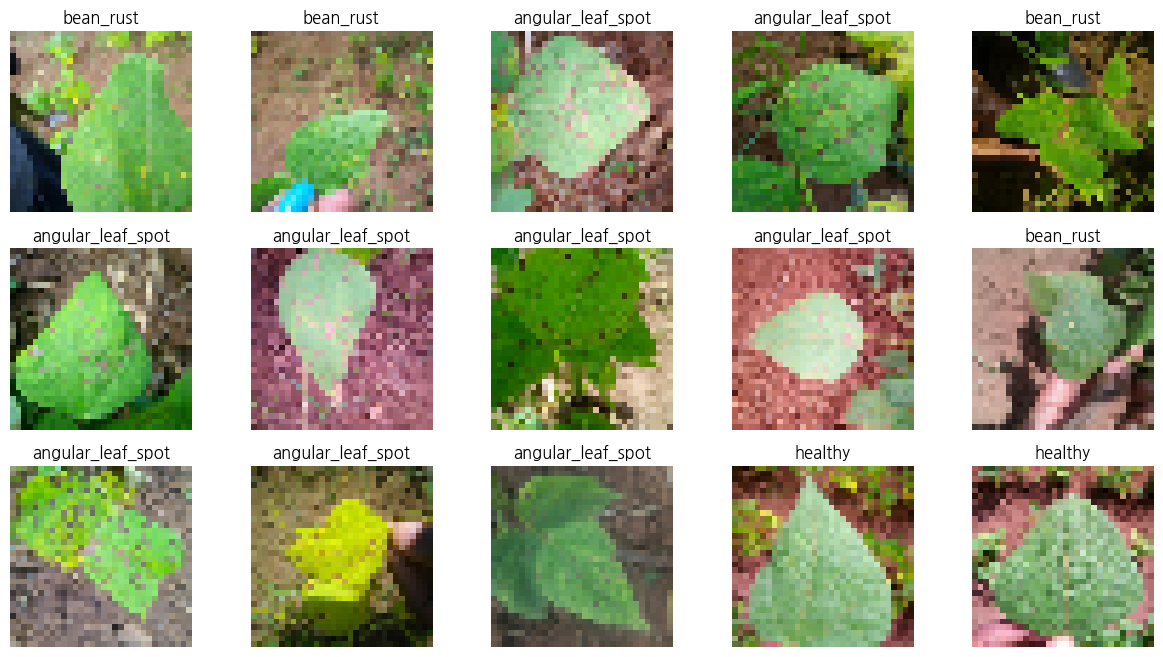

In [5]:
class_labels=['angular_leaf_spot', 'bean_rust', 'healthy']

# 처음 15개 이미지 출력
plt.figure(figsize=(15,8))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(x_train[i])
    plt.axis("off")
    plt.title(f"{class_labels[y_train[i]]}")
plt.show()

In [ ]:
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

input_shape=x_train[0].shape
patch_size=4
embed_dim=64
num_heads=4

ViT=Sequential([
    Input(shape=input_shape),
    # 모델 내부에서 입력 이미지를 랜덤 변환(온라인 데이터 증강)
    RandomFlip("horizontal&vertical"),
    RandomRotation(0.2),
    RandomZoom(0.1),
    RandomContrast(0.1),

    # 임베딩+포지션_인코딩
    PatchEmbedding(patch_size, embed_dim),

    # 셀프어텐션+FFN
    TransformerBlock(num_heads),
    TransformerBlock(num_heads),
    TransformerBlock(num_heads),
    TransformerBlock(num_heads),
    TransformerBlock(num_heads),

    # 각 토큰의 벡터 요약
    GlobalAveragePooling1D(),

    # 완전연결망으로 연결
    Dense(128, activation='elu'),
    Dropout(0.3),
    Dense(len(class_labels), activation='softmax')
    ])

early_stop= EarlyStopping(monitor='val_loss',
    patience=30, restore_best_weights=True)
ViT.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

history = ViT.fit(x_train, y_train, validation_data=(x_test, y_test),
    epochs=300, batch_size=32, callbacks=[early_stop])

Epoch 1/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - accuracy: 0.3791 - loss: 1.5020 - val_accuracy: 0.3594 - val_loss: 1.2021
Epoch 2/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.4130 - loss: 1.1696 - val_accuracy: 0.4766 - val_loss: 1.0150
Epoch 3/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4700 - loss: 1.1479 - val_accuracy: 0.5625 - val_loss: 0.9694
Epoch 4/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4739 - loss: 1.0837 - val_accuracy: 0.6641 - val_loss: 0.8423
Epoch 5/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5019 - loss: 1.0528 - val_accuracy: 0.6328 - val_loss: 0.8354
Epoch 6/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5513 - loss: 0.9686 - val_accuracy: 0.7109 - val_loss: 0.7744
Epoch 7/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5735 - loss: 0.9309 - val_accuracy: 0.6953 - val_loss: 0.7048
Epoch 8/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6441 - loss: 0.8015 - val_accuracy: 0

📌학습된 모형의 예측 정확도 시각화하기

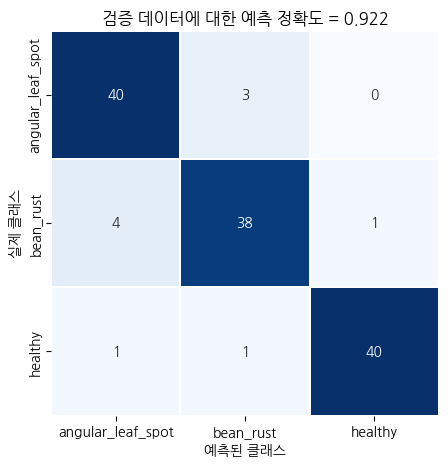

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
y_prob=ViT.predict(x_test, verbose=0)  # 클래스별 확률 예측
y_pred=np.argmax(y_prob, axis=1)       # max 확률 인덱스

# 검증용 데이터셋에 대한 혼동행렬 생성
cm=confusion_matrix(y_test, y_pred)
# 분류 정확도 계산
acc=accuracy_score(y_test, y_pred)
# 혼동행렬 시각화 (이전 코드 재활용)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True,fmt="d", linewidths=0.1, cmap='Blues',cbar=None,
            xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('실제 클래스'); plt.xlabel('예측된 클래스')
plt.title(f"검증 데이터에 대한 예측 정확도 = {acc:.3f}")
plt.show()